# Sales Analytics Project with Pythone

In [3]:
# import All library for code

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import math as mt

# Load Dataset And Read the Data 

In [4]:

df = pd.read_csv(
    r'C:\Users\abcom\OneDrive\Documents\All_project\5top\DATA endtoend\Sample_Superstore.csv',
    encoding='latin1'
)

In [5]:
df.head()
df.tail()
df.shape
df.columns
df.info()
df.describe


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row_ID          9994 non-null   int64  
 1   Order_ID        9994 non-null   object 
 2   Order_Date      9994 non-null   object 
 3   Order_Day       9994 non-null   object 
 4   Order_month     9994 non-null   object 
 5   Quarter         9994 non-null   object 
 6   Order_year      9994 non-null   int64  
 7   Ship_Date       9994 non-null   object 
 8   Shiping_days    9994 non-null   int64  
 9   Ship_Mode       9994 non-null   object 
 10  Customer_ID     9994 non-null   object 
 11  Customer_Name   9994 non-null   object 
 12  Segment         9994 non-null   object 
 13  Country         9994 non-null   object 
 14  City            9994 non-null   object 
 15  State           9994 non-null   object 
 16  Postal_Code     9994 non-null   int64  
 17  Region          9994 non-null   o

<bound method NDFrame.describe of       Row_ID        Order_ID Order_Date Order_Day Order_month Quarter  \
0          1  CA-2016-152156  08-Nov-16   Tuesday    November      Q4   
1          2  CA-2016-152156  08-Nov-16   Tuesday    November      Q4   
2          3  CA-2016-138688  12-Jun-16    Sunday        June      Q2   
3          4  US-2015-108966  11-Oct-15    Sunday     October      Q4   
4          5  US-2015-108966  11-Oct-15    Sunday     October      Q4   
...      ...             ...        ...       ...         ...     ...   
9989    9990  CA-2014-110422  21-Jan-14   Tuesday     January      Q1   
9990    9991  CA-2017-121258  26-Feb-17    Sunday    February      Q1   
9991    9992  CA-2017-121258  26-Feb-17    Sunday    February      Q1   
9992    9993  CA-2017-121258  26-Feb-17    Sunday    February      Q1   
9993    9994  CA-2017-119914  04-May-17  Thursday         May      Q2   

      Order_year  Ship_Date  Shiping_days       Ship_Mode  ... Region  \
0           2016

# Data Cleaning

In [6]:
# Missing Values Check 
df.isnull().sum()

# Duplicate Values Check  
df.duplicated().sum()

# Data Types Check 
df.dtypes

# change in data type for date and profite marging
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'])



C:\Users\abcom\AppData\Local\Temp\ipykernel_16504\405499127.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order_Date'] = pd.to_datetime(df['Order_Date'])
C:\Users\abcom\AppData\Local\Temp\ipykernel_16504\405499127.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Ship_Date'] = pd.to_datetime(df['Ship_Date'])


# Exploratory Data Analysis (EDA)

In [7]:
# Total Sales calculate 
Total_Sales = df['Sales'].sum()
print("Total Sales :- ",Total_Sales)



Total Sales :-  2297201.07


In [8]:
# 2. Total Profit
Total_Profit = df['Profit'].sum()
print("Total Profite is : ", Total_Profit)

Total Profite is :  286397.79


In [9]:
# Total Orders
Total_order = df['Order_ID'].nunique()
print("Totol Order : ",  Total_order)

Totol Order :  5009


In [10]:
# Total Customers
Total_cst = df['Customer_ID'].nunique()
print("Total Customer is : ", Total_cst)

Total Customer is :  793


# Business Analysis 

In [11]:
# 1. Sales by Category
Sales_catagory = df.groupby('Category')['Sales'].sum()
print(" Sales by Category is :", Sales_catagory)


 Sales by Category is : Category
Furniture          741999.98
Office Supplies    719046.99
Technology         836154.10
Name: Sales, dtype: float64


In [12]:
# Sales by Sub-Category
sub_cat_sale = df.groupby('Sub_Category')['Sales'].sum()
print("Total sales by sub catagory :",sub_cat_sale)


Total sales by sub catagory : Sub_Category
Accessories    167380.31
Appliances     107532.14
Art             27118.80
Binders        203412.77
Bookcases      114880.05
Chairs         328449.13
Copiers        149528.01
Envelopes       16476.38
Fasteners        3024.25
Furnishings     91705.12
Labels          12486.30
Machines       189238.68
Paper           78479.24
Phones         330007.10
Storage        223843.59
Supplies        46673.52
Tables         206965.68
Name: Sales, dtype: float64


In [13]:
# Sales by Region
Sales_by_Region = df.groupby('Region')['Sales'].sum()
print("Total Sales By region Is :", Sales_by_Region)

Total Sales By region Is : Region
Central    501239.88
East       678781.36
South      391721.90
West       725457.93
Name: Sales, dtype: float64


In [14]:
# Sales by State
Sales_by_State = df.groupby('State')['Sales'].sum()
print("Total sales by states :", Sales_by_State)

Total sales by states : State
Alabama                  19510.64
Arizona                  35282.02
Arkansas                 11678.13
California              457687.68
Colorado                 32108.12
Connecticut              13384.36
Delaware                 27451.07
District of Columbia      2865.02
Florida                  89473.73
Georgia                  49095.84
Idaho                     4382.49
Illinois                 80166.16
Indiana                  53555.36
Iowa                      4579.76
Kansas                    2914.31
Kentucky                 36591.75
Louisiana                 9217.03
Maine                     1270.53
Maryland                 23705.52
Massachusetts            28634.44
Michigan                 76269.61
Minnesota                29863.15
Mississippi              10771.34
Missouri                 22205.15
Montana                   5589.35
Nebraska                  7464.93
Nevada                   16729.10
New Hampshire             7292.52
New Jersey        

In [15]:
# Sales by Segment
Sales_by_segment = df.groupby('Segment')['Sales'].sum()
print("Total Sales by Segment  ", Sales_by_segment)


Total Sales by Segment   Segment
Consumer       1161401.34
Corporate       706146.44
Home Office     429653.29
Name: Sales, dtype: float64


In [16]:
# Sales by Ship-mode
Sales_by_shipmode = df.groupby('Ship_Mode')['Sales'].sum()
print("Total sales by states :", Sales_by_shipmode)

Total sales by states : Ship_Mode
First Class        351428.43
Same Day           128363.12
Second Class       459193.44
Standard Class    1358216.08
Name: Sales, dtype: float64


In [17]:
# Monthly Sales Trend
Monthly_sales = df.groupby('Order_month')['Sales'].sum()
print("Monthly Sales Trend", Monthly_sales)

Monthly Sales Trend Order_month
April        137762.16
August       159043.99
December     325293.54
February      59751.26
January       94924.87
July         147238.11
June         152718.72
March        205005.51
May          155028.83
November     352461.09
October      200323.03
September    307649.96
Name: Sales, dtype: float64


In [18]:
# Months ko orders Krna 
month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

df['Order_month'] = pd.Categorical(
    df['Order_month'],
    categories=month_order,
    ordered=True
)

Monthly_sales = df.groupby(
    'Order_month',
    observed=False
)['Sales'].sum()

Monthly_sales

Order_month
January       94924.87
February      59751.26
March        205005.51
April        137762.16
May          155028.83
June         152718.72
July         147238.11
August       159043.99
September    307649.96
October      200323.03
November     352461.09
December     325293.54
Name: Sales, dtype: float64

In [31]:
# Top 10 Customers
Top_customer = df.groupby('Customer_Name')['Sales'].sum()
Top_10_cst = Top_customer.sort_values( ascending= False  ).head(10)
Top_10_cst

Customer_Name
Sean Miller           25043.07
Tamara Chand          19052.22
Raymond Buch          15117.35
Tom Ashbrook          14595.62
Adrian Barton         14473.57
Ken Lonsdale          14175.23
Sanjit Chand          14142.34
Hunter Lopez          12873.30
Sanjit Engle          12209.44
Christopher Conant    12129.08
Name: Sales, dtype: float64

In [32]:
# Top 10 Products
Top_product = df.groupby('Product_Name')['Sales'].sum()
Top_10_product = Top_product.sort_values(ascending=False).head(10)
Top_10_product

Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.83
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.38
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.48
HON 5400 Series Task Chairs for Big and Tall                                   21870.57
GBC DocuBind TL300 Electric Binding System                                     19823.48
GBC Ibimaster 500 Manual ProClick Binding System                               19024.50
Hewlett Packard LaserJet 3310 Copier                                           18839.68
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.90
GBC DocuBind P400 Electric Binding System                                      17965.07
High Speed Automatic Electric Letter Opener                                    17030.31
Name: Sales, dtype: float64

In [21]:
# Profit by Category
Profite_by_category = df.groupby('Category')['Sales'].sum()
print("Profite by Category ", Profite_by_category)

Profite by Category  Category
Furniture          741999.98
Office Supplies    719046.99
Technology         836154.10
Name: Sales, dtype: float64


In [53]:
# Correlation Heatmap
corr = df[['Sales','Quantity','Discount','Profit']].corr()

corr

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.027588,0.479064
Quantity,0.200795,1.000000,0.008655,0.066253
Discount,-0.027588,0.008655,1.000000,-0.219582
Profit,0.479064,0.066253,-0.219582,1.000000


In [22]:
# Discount vs Profit
Discount_Profit = df.groupby('Discount')['Profit'].sum()
print("Discount vs Profit trends : " , Discount_Profit)

Discount vs Profit trends :  Discount
0.0    320987.88
0.1      9029.21
0.2     91757.14
0.3    -12760.50
0.4    -23057.08
0.5    -22999.63
0.6     -5944.64
0.7    -40075.46
0.8    -30539.13
Name: Profit, dtype: float64


# Data Visualization By Charg and Graph

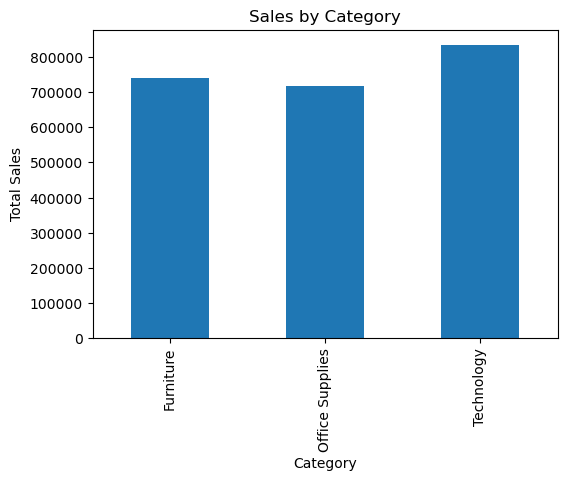

In [23]:
# Sales by Category 
plt.figure(figsize=(6,4)) 
Sales_catagory.plot(kind='bar')
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

## Sales by Category

* Technology category generated the highest sales compared to other categories.
* Furniture and Office Supplies contributed less revenue.
* More focus can be given to high-performing categories to increase sales.

<function matplotlib.pyplot.show(close=None, block=None)>

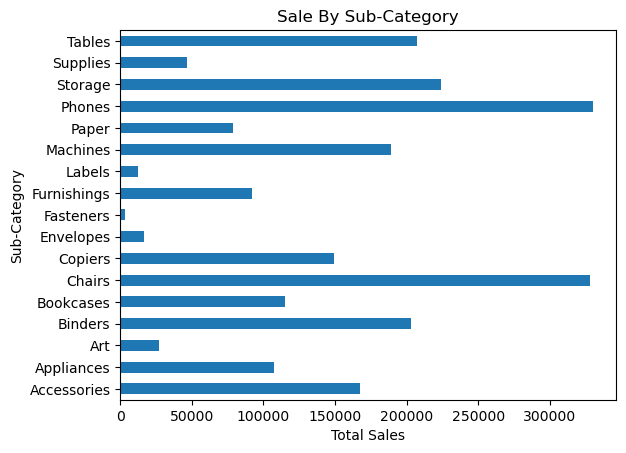

In [24]:
# Sales by Sub-Category
sub_cat_sale.plot(kind="barh")
plt.title("Sale By Sub-Category")
plt.ylabel("Sub-Category")
plt.xlabel("Total Sales")
plt.show

##  Sales by Sub-Category

* A few sub-categories contribute a major share of total sales.
* Top-performing sub-categories should be maintained with proper inventory.
* Low-performing sub-categories need improvement strategies.


<function matplotlib.pyplot.show(close=None, block=None)>

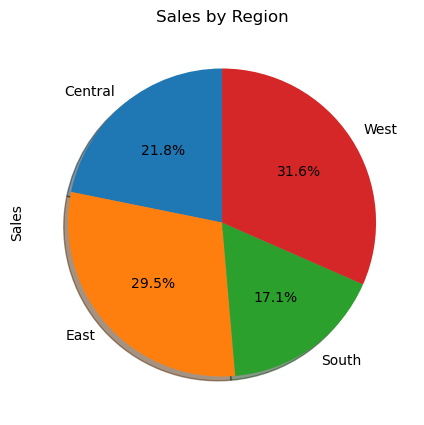

In [25]:
# Sales by Region
plt.figure(figsize= (5,5))
Sales_by_Region.plot(kind= "pie", autopct='%1.1f%%', shadow = True  , startangle = 90 )
plt.title("Sales by Region")
plt.show

## Sales by Region

* Some regions are generating higher sales compared to others.
* High-performing regions are the major contributors to business revenue.
* Sales opportunities exist in low-performing regions.

<function matplotlib.pyplot.show(close=None, block=None)>

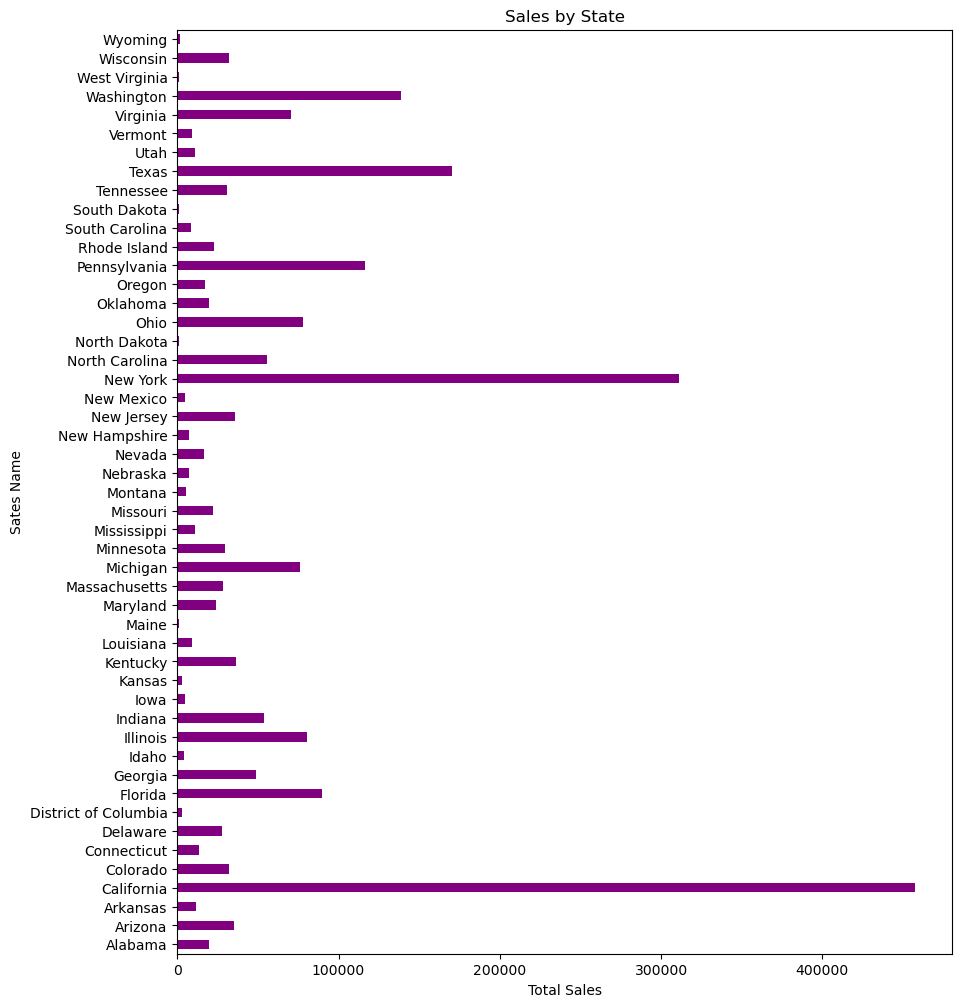

In [26]:
# Sales by State
plt.figure(figsize=(10,12) )
Sales_by_State.plot(kind= 'barh', color='purple')
plt.title("Sales by State")
plt.xlabel("Total Sales")
plt.ylabel("Sates Name")
plt.show


## Sales by State

* A few states contribute significantly to total sales.
* Top-performing states are important markets for the business.
* Marketing strategies can be improved in low-sales states.

<function matplotlib.pyplot.show(close=None, block=None)>

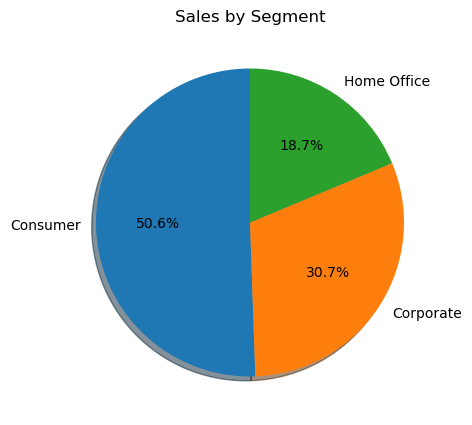

In [27]:
# Sales by Segment
plt.figure(figsize=(5,5))
Sales_by_segment.plot(kind= "pie" , autopct = "%1.1f%%" , shadow = True , startangle = 90)
plt.title("Sales by Segment")
plt.ylabel(" ")
plt.show

## Sales by Segment

* Consumer segment contributes the highest sales among all segments.
* Corporate and Home Office segments also contribute to overall revenue.
* Segment-wise strategies can help improve customer targeting.



<function matplotlib.pyplot.show(close=None, block=None)>

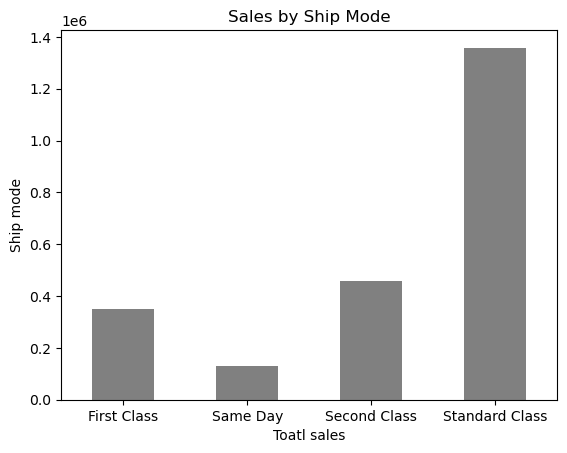

In [28]:
# Sales by Ship Mode
plt.Figure(figsize= (5,4))
Sales_by_shipmode.plot(kind= "bar" , color='gray')
plt.title("Sales by Ship Mode")
plt.xlabel("Toatl sales")
plt.xticks(rotation= 360)
plt.ylabel("Ship mode")
plt.show

## Sales by Ship Mode

* Some shipping modes are more preferred by customers.
* Popular shipping methods should be maintained for better customer experience.
* Delivery performance can be improved by optimizing shipping operations.



<function matplotlib.pyplot.show(close=None, block=None)>

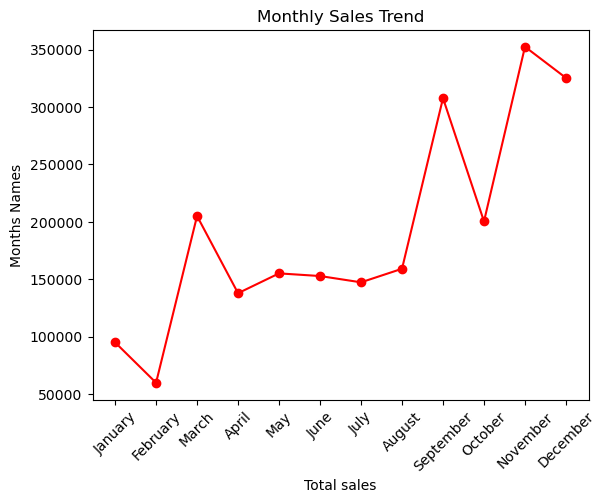

In [29]:
# Monthly Sales Trend
plt.Figure(figsize=(7,5))

Monthly_sales.plot(kind='line' , marker = 'o', color='red' )
plt.title("Monthly Sales Trend") 
plt.xlabel("Total sales")
plt.xticks(
    range(len(Monthly_sales.index)),
    Monthly_sales.index,
    rotation=45
)
plt.xticks(rotation=45)
plt.ylabel("Months Names")
plt.show

## Monthly Sales Trend

* Sales show variations across different months.
* Certain months generate higher sales compared to others.
* Demand forecasting and inventory planning are important during peak months.


<function matplotlib.pyplot.show(close=None, block=None)>

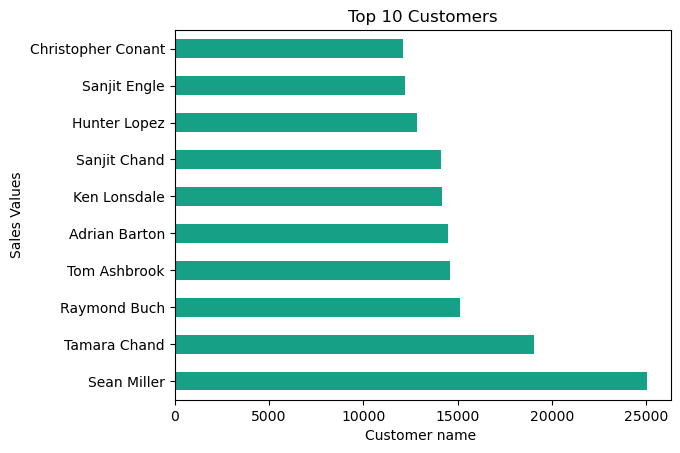

In [35]:
# Top 10 Customers
Top_10_cst.plot(kind="barh" , color='#16A085')
plt.title("Top 10 Customers")
plt.xlabel("Customer name ")
plt.ylabel("Sales Values")
plt.show

## Top 10 Customers

* A small number of customers contribute a significant portion of sales.
* High-value customers should be retained through better customer relationships.
* Customer loyalty programs can help increase repeat purchases.

<function matplotlib.pyplot.show(close=None, block=None)>

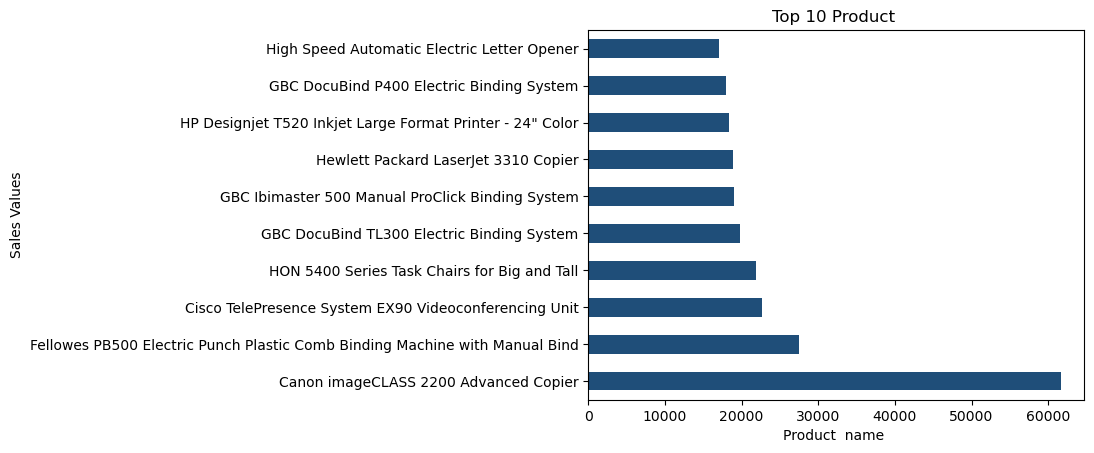

In [37]:
# Top 10 Products
Top_10_product.plot(kind="barh" , color='#1F4E79')
plt.title("Top 10 Product ")
plt.xlabel("Product  name ")
plt.ylabel("Sales Values")
plt.show

## Top 10 Products

* Top products generate a major share of overall sales.
* These products should always have sufficient stock availability.
* Low-performing products need further analysis for improvement.

<function matplotlib.pyplot.show(close=None, block=None)>

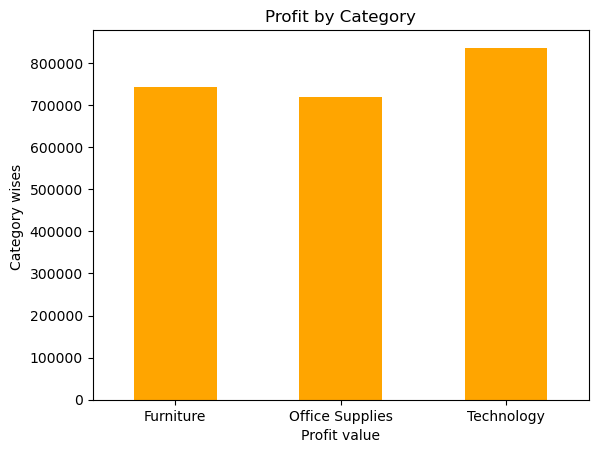

In [41]:
# Profit by Category
Profite_by_category.plot(kind= 'bar', color='orange' )
plt.title("Profit by Category")
plt.xlabel("Profit value")
plt.xticks(rotation = 360)
plt.ylabel("Category wises ")   
plt.show 

## Profit by Category

* Some categories generate higher profits compared to others.
* High-profit categories should receive more business focus.
* Cost control is required for low-profit categories.


<function matplotlib.pyplot.show(close=None, block=None)>

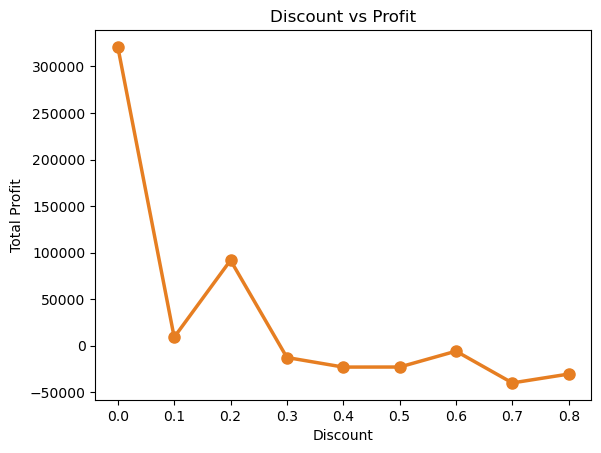

In [52]:
# Discount vs Profit

Discount_Profit.plot(
    kind='line',
    color='#E67E22',
    marker='o',
    linewidth=2.5,
    markersize=8
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Total Profit")
plt.show

## Discount vs Profit

* Higher discounts may reduce overall profit margins.
* Discount strategies should be planned carefully.
* A balanced discount approach can help maintain both sales and profitability.



<function matplotlib.pyplot.show(close=None, block=None)>

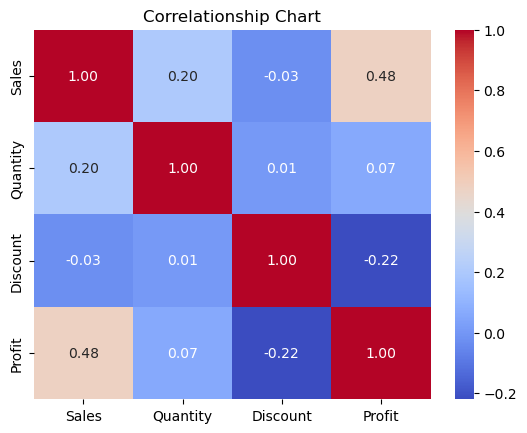

In [54]:
# Correlationship Chart
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlationship Chart")
plt.show

### 📊 Insight: Correlation Heatmap

**1. Sales vs Profit (0.48)**
- There is a **moderate positive correlation** between Sales and Profit.
- Higher sales generally lead to higher profits, but the relationship is not perfect because discounts and product costs also affect profit.

---

**2. Sales vs Quantity (0.20)**
- There is a **weak positive correlation** between Sales and Quantity.
- Selling more units does not always result in significantly higher sales, as product prices vary across categories.

---

**3. Discount vs Profit (-0.22)**
- There is a **weak negative correlation** between Discount and Profit.
- Increasing discounts tends to reduce profitability, indicating that excessive discounting can negatively impact business profits.

---

**4. Discount vs Sales (-0.03)**
- There is **almost no correlation** between Discount and Sales.
- Discounts alone do not have a significant impact on overall sales performance.

---

**5. Quantity vs Profit (0.07)**
- There is a **very weak positive correlation** between Quantity and Profit.
- Selling more items does not necessarily generate higher profits because profit also depends on product margins and discount levels.


## Final Reports OR  Overall Business Insight

## Overall Project Insights

- The analysis shows that sales performance is mainly driven by the Technology category, which contributes significantly to overall revenue.

- The Consumer segment is the largest revenue contributor, indicating that individual customers are the key target group for the business.

- A small number of top customers and products generate a major portion of sales, so customer retention and product availability are important for growth.

- Sales performance varies across different regions and states, which shows opportunities to improve sales in low-performing areas.

- Monthly sales trends show fluctuations throughout the year, highlighting the importance of demand forecasting and inventory planning.

- The analysis of discounts and profit indicates that excessive discounts can negatively impact profitability, so discount strategies should be planned carefully.

- Overall, the business can improve revenue and profitability by focusing on high-performing categories, retaining valuable customers, optimizing pricing strategies, and improving performance in weaker markets.

In [59]:
df.to_csv(r"C:\Users\abcom\OneDrive\Desktop\clean_data.csv", index=False)